# 07 - GNN sur Elliptic Bitcoin Dataset : GCN vs GAT

Objectif : répondre à la partie du sujet qui demande de charger **Elliptic Bitcoin Dataset**, entraîner un **GCN**, entraîner un **GAT**, comparer **recall**, **AUPRC** et **temps d'inférence**, puis expliquer pourquoi GAT peut être supérieur à GCN.

Ce notebook est volontairement séparé du dataset IEEE-CIS : Elliptic est un dataset graphe Bitcoin différent. Il sert à tester des modèles GNN purs sur un graphe de transactions.


## 1. Pré-requis

Le notebook utilise PyTorch et PyTorch Geometric. Si l'import échoue, installe les dépendances dans le kernel Jupyter utilisé pour ce notebook.

Commande typique CPU :

```bash
pip install torch torch_geometric scikit-learn pandas matplotlib seaborn
```

Le chargement essaie d'abord `torch_geometric.datasets.EllipticBitcoinDataset`. Si ce chemin ne fonctionne pas, place les fichiers CSV bruts dans `data/elliptic/` :

- `elliptic_txs_features.csv`
- `elliptic_txs_classes.csv`
- `elliptic_txs_edgelist.csv`


In [1]:
from pathlib import Path
import json
import time
import warnings

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
ELLIPTIC_DIR = DATA_DIR / "elliptic"
ASSETS_DIR = PROJECT_ROOT / "docs" / "assets"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
MAX_EPOCHS = 120
PATIENCE = 15
HIDDEN_CHANNELS = 64
DROPOUT = 0.35
LEARNING_RATE = 0.005
WEIGHT_DECAY = 5e-4

print("Projet :", PROJECT_ROOT)
print("Dossier Elliptic attendu :", ELLIPTIC_DIR)


Projet : /mnt/c/Users/tanjo/projetcs/fraud-scope
Dossier Elliptic attendu : /mnt/c/Users/tanjo/projetcs/fraud-scope/data/elliptic


In [2]:
try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import average_precision_score, recall_score, precision_score, f1_score, confusion_matrix
    from sklearn.preprocessing import StandardScaler
    import torch
    import torch.nn.functional as F
    from torch import nn
    from torch_geometric.data import Data
    from torch_geometric.nn import GCNConv, GATConv
    try:
        from torch_geometric.datasets import EllipticBitcoinDataset
    except Exception:
        EllipticBitcoinDataset = None
except Exception as exc:
    raise ImportError(
        "Dependances manquantes. Installe dans ce kernel : "
        "pip install torch torch_geometric scikit-learn pandas matplotlib seaborn"
    ) from exc

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)
print("Torch :", torch.__version__)


Device : cpu
Torch : 2.12.1+cu130


## 2. Chargement du dataset Elliptic

On supporte deux formats :

1. chargement direct via PyTorch Geometric ;
2. chargement manuel depuis les CSV bruts.

Les classes Elliptic sont généralement :

- `1` = illicit / fraude ;
- `2` = licit / normal ;
- `unknown` = non labellisé, utilisé seulement comme contexte de graphe.

Pour les métriques supervisées, on évalue uniquement les nœuds labellisés licites ou illicites.


In [3]:
def load_from_pyg(root: Path):
    if EllipticBitcoinDataset is None:
        raise RuntimeError("EllipticBitcoinDataset non disponible dans torch_geometric.datasets")
    dataset = EllipticBitcoinDataset(root=str(root))
    data = dataset[0]
    if not hasattr(data, "x") or not hasattr(data, "edge_index") or not hasattr(data, "y"):
        raise RuntimeError("Objet PyG Elliptic incomplet : x, edge_index ou y manquant")
    return data, "pyg"


def load_from_raw_csv(root: Path):
    features_path = root / "elliptic_txs_features.csv"
    classes_path = root / "elliptic_txs_classes.csv"
    edges_path = root / "elliptic_txs_edgelist.csv"
    missing = [p.name for p in [features_path, classes_path, edges_path] if not p.exists()]
    if missing:
        raise FileNotFoundError(
            "Fichiers Elliptic absents : " + ", ".join(missing) +
            f". Place-les dans {root} ou utilise le loader PyG."
        )

    features = pd.read_csv(features_path, header=None)
    classes = pd.read_csv(classes_path)
    edges = pd.read_csv(edges_path)

    feature_cols = ["txId", "time_step"] + [f"feat_{i}" for i in range(features.shape[1] - 2)]
    features.columns = feature_cols

    if list(classes.columns)[:2] != ["txId", "class"]:
        classes.columns = ["txId", "class"]
    if list(edges.columns)[:2] != ["txId1", "txId2"]:
        edges.columns = ["txId1", "txId2"]

    df = features.merge(classes, on="txId", how="left")
    tx_to_idx = {tx: idx for idx, tx in enumerate(df["txId"].values)}

    edge_src = edges["txId1"].map(tx_to_idx)
    edge_dst = edges["txId2"].map(tx_to_idx)
    edge_df = pd.DataFrame({"src": edge_src, "dst": edge_dst}).dropna().astype(int)

    # Graphe non orienté pour les convolutions GNN.
    edge_index_np = np.vstack([
        np.concatenate([edge_df["src"].values, edge_df["dst"].values]),
        np.concatenate([edge_df["dst"].values, edge_df["src"].values]),
    ])

    x_np = df[[c for c in df.columns if c.startswith("feat_")]].astype("float32").values
    x_np = StandardScaler().fit_transform(x_np).astype("float32")

    # y = 1 pour illicit, 0 pour licit, -1 pour unknown.
    class_str = df["class"].astype(str).str.lower()
    y_np = np.full(len(df), -1, dtype=np.int64)
    y_np[class_str.isin(["1", "illicit"])] = 1
    y_np[class_str.isin(["2", "licit"])] = 0

    data = Data(
        x=torch.tensor(x_np, dtype=torch.float),
        edge_index=torch.tensor(edge_index_np, dtype=torch.long),
        y=torch.tensor(y_np, dtype=torch.long),
    )
    data.time_step = torch.tensor(df["time_step"].values, dtype=torch.long)
    return data, "raw_csv"


try:
    data, data_source = load_from_pyg(ELLIPTIC_DIR)
except Exception as pyg_exc:
    print("Chargement PyG indisponible, tentative CSV brut.")
    print("Raison PyG :", repr(pyg_exc))
    data, data_source = load_from_raw_csv(ELLIPTIC_DIR)

def normalize_elliptic_labels(data):
    """Ramene les labels au format binaire : 1=fraude, 0=normal, -1=inconnu."""
    y = data.y.detach().cpu().clone().long()
    unique = sorted(set(y.numpy().tolist()))
    # Certains loaders PyG codent unknown=2. On l'exclut des métriques supervisées.
    if 2 in unique and -1 not in unique:
        y[y == 2] = -1
    data.y = y
    return data

data = normalize_elliptic_labels(data)

print("Source :", data_source)
print(data)
print("Noeuds :", data.num_nodes)
print("Aretes orientées dans edge_index :", data.edge_index.shape[1])
print("Features :", data.num_node_features)
print("Labels uniques normalisés :", sorted(set(data.y.cpu().numpy().tolist())))


Processing...
Done!


Source : pyg
Data(x=[203769, 165], edge_index=[2, 234355], y=[203769], train_mask=[203769], test_mask=[203769])
Noeuds : 203769
Aretes orientées dans edge_index : 234355
Features : 165
Labels uniques normalisés : [-1, 0, 1]


## 3. Split temporel train / validation / test

Elliptic est un dataset temporel. Pour éviter une fuite temporelle, on sépare par `time_step` quand cette information est disponible.

Les nœuds `unknown` restent dans le graphe pour transmettre l'information de voisinage, mais ils ne participent pas à la loss ni aux métriques.


In [4]:
def build_masks(data):
    y = data.y.cpu().numpy()
    labelled = y >= 0

    if hasattr(data, "time_step"):
        ts = data.time_step.cpu().numpy()
    elif hasattr(data, "t"):
        ts = data.t.cpu().numpy()
    else:
        # Fallback : split déterministe par ordre des noeuds si le temps n'est pas exposé par le loader.
        ts = np.arange(data.num_nodes)

    labelled_steps = ts[labelled]
    q_train, q_valid = np.quantile(labelled_steps, [0.60, 0.80])

    train_mask_np = labelled & (ts <= q_train)
    valid_mask_np = labelled & (ts > q_train) & (ts <= q_valid)
    test_mask_np = labelled & (ts > q_valid)

    data.train_mask = torch.tensor(train_mask_np, dtype=torch.bool)
    data.val_mask = torch.tensor(valid_mask_np, dtype=torch.bool)
    data.test_mask = torch.tensor(test_mask_np, dtype=torch.bool)
    return data


data = build_masks(data)

for name, mask in [("train", data.train_mask), ("valid", data.val_mask), ("test", data.test_mask)]:
    yy = data.y[mask].cpu().numpy()
    print(
        name,
        "n=", int(mask.sum()),
        "fraud_rate=", float((yy == 1).mean()) if len(yy) else None,
        "fraud_count=", int((yy == 1).sum()) if len(yy) else 0,
    )


train n= 27938 fraud_rate= 0.11196220201875581 fraud_count= 3128
valid n= 9313 fraud_rate= 0.10136368517126597 fraud_count= 944
test n= 9313 fraud_rate= 0.05078921937077204 fraud_count= 473


## 4. Modèles GCN et GAT

- **GCN** agrège les voisins avec une normalisation fixe du graphe.
- **GAT** apprend des poids d'attention entre voisins, ce qui peut mieux gérer les graphes hétérogènes où certains voisins sont plus informatifs que d'autres.


In [5]:
class GCNNet(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, dropout=0.35):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, 2)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x


class GATNet(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, heads=4, dropout=0.35):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_channels * heads, 2, heads=1, concat=False, dropout=dropout)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x


In [6]:
def compute_class_weights(y, mask):
    yy = y[mask]
    n0 = int((yy == 0).sum())
    n1 = int((yy == 1).sum())
    total = max(n0 + n1, 1)
    # Poids inverse fréquence pour compenser le déséquilibre fraude / non fraude.
    w0 = total / max(2 * n0, 1)
    w1 = total / max(2 * n1, 1)
    return torch.tensor([w0, w1], dtype=torch.float)


def evaluate_model(model, data, mask, threshold=0.5):
    model.eval()
    start = time.perf_counter()
    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        probs_all = F.softmax(logits, dim=1)[:, 1]
    inference_time = time.perf_counter() - start

    y_true = data.y[mask].detach().cpu().numpy()
    scores = probs_all[mask].detach().cpu().numpy()
    preds = (scores >= threshold).astype(int)

    return {
        "AUPRC": average_precision_score(y_true, scores),
        "recall": recall_score(y_true, preds, zero_division=0),
        "precision": precision_score(y_true, preds, zero_division=0),
        "F1": f1_score(y_true, preds, zero_division=0),
        "inference_time_sec": inference_time,
        "inference_ms_per_node": inference_time / max(int(mask.sum()), 1) * 1000,
        "scores": scores,
        "preds": preds,
        "y_true": y_true,
    }


def train_gnn(model_name, model, data):
    model = model.to(device)
    data_dev = data.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    class_weights = compute_class_weights(data_dev.y, data_dev.train_mask).to(device)

    best_state = None
    best_val_auprc = -1
    best_epoch = 0
    patience_left = PATIENCE
    history = []
    start_train = time.perf_counter()

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        optimizer.zero_grad()
        logits = model(data_dev.x, data_dev.edge_index)
        loss = F.cross_entropy(logits[data_dev.train_mask], data_dev.y[data_dev.train_mask], weight=class_weights)
        loss.backward()
        optimizer.step()

        val_metrics = evaluate_model(model, data_dev, data_dev.val_mask)
        row = {"epoch": epoch, "loss": float(loss.item()), "val_AUPRC": val_metrics["AUPRC"], "val_recall": val_metrics["recall"]}
        history.append(row)

        if val_metrics["AUPRC"] > best_val_auprc:
            best_val_auprc = val_metrics["AUPRC"]
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_left = PATIENCE
        else:
            patience_left -= 1

        if epoch % 10 == 0 or epoch == 1:
            print(f"{model_name} epoch {epoch:03d} loss={loss.item():.4f} val_AUPRC={val_metrics['AUPRC']:.4f} val_recall={val_metrics['recall']:.4f}")

        if patience_left <= 0:
            print(f"Early stopping {model_name} epoch {epoch}, meilleur epoch {best_epoch}")
            break

    train_time = time.perf_counter() - start_train
    model.load_state_dict(best_state)
    test_metrics = evaluate_model(model, data_dev, data_dev.test_mask)
    test_metrics["model"] = model_name
    test_metrics["best_epoch"] = best_epoch
    test_metrics["train_time_sec"] = train_time
    return model, pd.DataFrame(history), test_metrics


## 5. Entraînement

Le critère de sélection est l'AUPRC sur validation, puis on reporte les métriques sur test temporel.


In [8]:
results = []
histories = {}
trained_models = {}

model_specs = {
    "GCN": GCNNet(data.num_node_features, HIDDEN_CHANNELS, DROPOUT),
    "GAT": GATNet(data.num_node_features, HIDDEN_CHANNELS, heads=4, dropout=DROPOUT),
}

for model_name, model in model_specs.items():
    print("===", model_name, "===")
    trained_model, history, metrics = train_gnn(model_name, model, data)
    histories[model_name] = history
    trained_models[model_name] = trained_model
    results.append({k: v for k, v in metrics.items() if k not in ["scores", "preds", "y_true"]})

results_df = pd.DataFrame(results).sort_values("AUPRC", ascending=False).reset_index(drop=True)
display(results_df)

out_path = PROJECT_ROOT / "docs" / "gnn_elliptic_results.csv"
results_df.to_csv(out_path, index=False)
print("Résultats sauvegardés :", out_path)


=== GCN ===
GCN epoch 001 loss=1.2744 val_AUPRC=0.1287 val_recall=0.6653
GCN epoch 010 loss=0.3944 val_AUPRC=0.3288 val_recall=0.8792
GCN epoch 020 loss=0.3329 val_AUPRC=0.3728 val_recall=0.9047
GCN epoch 030 loss=0.2998 val_AUPRC=0.4420 val_recall=0.9047
GCN epoch 040 loss=0.2718 val_AUPRC=0.4829 val_recall=0.8930
GCN epoch 050 loss=0.2579 val_AUPRC=0.5249 val_recall=0.8930
GCN epoch 060 loss=0.2450 val_AUPRC=0.5657 val_recall=0.8877
GCN epoch 070 loss=0.2257 val_AUPRC=0.5916 val_recall=0.8538
GCN epoch 080 loss=0.2228 val_AUPRC=0.6358 val_recall=0.8199
GCN epoch 090 loss=0.2059 val_AUPRC=0.6468 val_recall=0.8167
GCN epoch 100 loss=0.2065 val_AUPRC=0.6208 val_recall=0.8157
GCN epoch 110 loss=0.2032 val_AUPRC=0.6645 val_recall=0.8008
GCN epoch 120 loss=0.1890 val_AUPRC=0.6545 val_recall=0.8242
=== GAT ===
GAT epoch 001 loss=0.9370 val_AUPRC=0.3048 val_recall=0.8242
GAT epoch 010 loss=0.4969 val_AUPRC=0.2548 val_recall=0.9481
GAT epoch 020 loss=0.4160 val_AUPRC=0.3630 val_recall=0.9619


,AUPRC,recall,precision,F1,inference_time_sec,inference_ms_per_node,model,best_epoch,train_time_sec
0,0.209137,0.477801,0.214625,0.296199,0.169384,0.018188,GCN,117,91.831153
1,0.168797,0.919662,0.078195,0.144135,0.806553,0.086605,GAT,26,156.747582


Résultats sauvegardés : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/gnn_elliptic_results.csv


## 6. Visualisations et artefacts


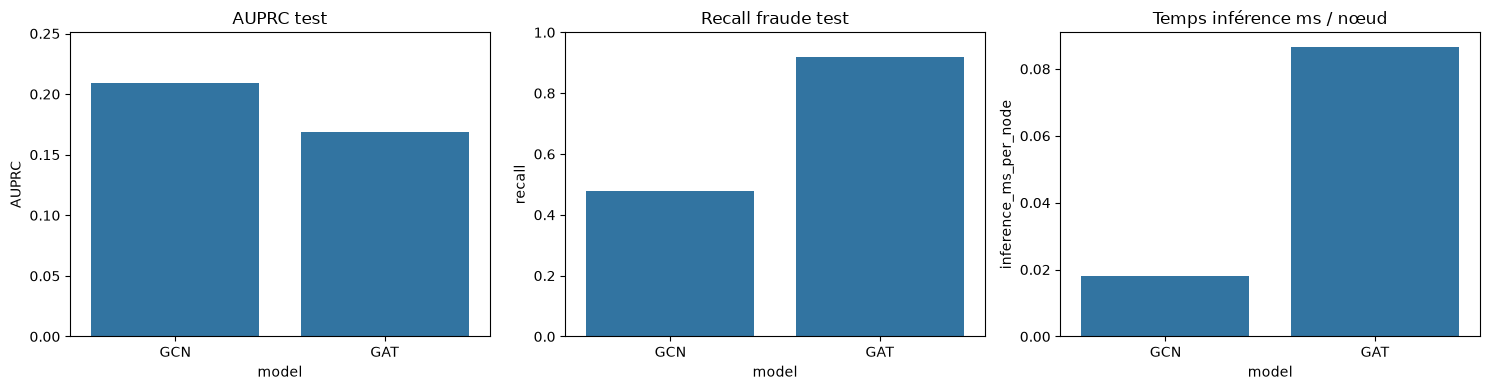

Figure sauvegardée : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/assets/07_gnn_gcn_gat_comparison.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(data=results_df, x="model", y="AUPRC", ax=axes[0])
axes[0].set_title("AUPRC test")
axes[0].set_ylim(0, min(1.0, max(results_df["AUPRC"].max() * 1.2, 0.1)))

sns.barplot(data=results_df, x="model", y="recall", ax=axes[1])
axes[1].set_title("Recall fraude test")
axes[1].set_ylim(0, 1)

sns.barplot(data=results_df, x="model", y="inference_ms_per_node", ax=axes[2])
axes[2].set_title("Temps inférence ms / nœud")

plt.tight_layout()
plot_path = ASSETS_DIR / "07_gnn_gcn_gat_comparison.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée :", plot_path)


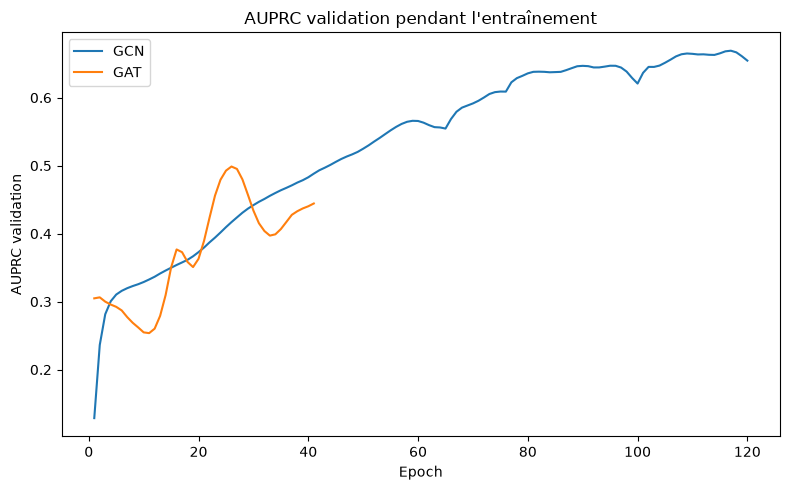

Figure sauvegardée : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/assets/07_gnn_training_curves.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
for model_name, hist in histories.items():
    ax.plot(hist["epoch"], hist["val_AUPRC"], label=model_name)
ax.set_title("AUPRC validation pendant l'entraînement")
ax.set_xlabel("Epoch")
ax.set_ylabel("AUPRC validation")
ax.legend()
plt.tight_layout()
plot_path = ASSETS_DIR / "07_gnn_training_curves.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée :", plot_path)


In [11]:
summary = {
    "dataset_source": data_source,
    "num_nodes": int(data.num_nodes),
    "num_edges_edge_index": int(data.edge_index.shape[1]),
    "num_features": int(data.num_node_features),
    "train_nodes": int(data.train_mask.sum()),
    "valid_nodes": int(data.val_mask.sum()),
    "test_nodes": int(data.test_mask.sum()),
    "best_model_by_AUPRC": str(results_df.iloc[0]["model"]),
    "best_AUPRC": float(results_df.iloc[0]["AUPRC"]),
}
summary_path = PROJECT_ROOT / "docs" / "gnn_elliptic_summary.json"
summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")
print(json.dumps(summary, indent=2))
print("Résumé sauvegardé :", summary_path)


{
  "dataset_source": "pyg",
  "num_nodes": 203769,
  "num_edges_edge_index": 234355,
  "num_features": 165,
  "train_nodes": 27938,
  "valid_nodes": 9313,
  "test_nodes": 9313,
  "best_model_by_AUPRC": "GCN",
  "best_AUPRC": 0.20913747820365808
}
Résumé sauvegardé : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/gnn_elliptic_summary.json


## 7. Interprétation attendue

À compléter avec les résultats réels après exécution :

- si **GAT** dépasse **GCN** en AUPRC ou recall, l'explication probable est que l'attention apprend à pondérer les voisins utiles, alors que GCN moyenne les voisins de manière plus uniforme ;
- si **GCN** est proche ou meilleur, cela peut indiquer que les features tabulaires des nœuds portent déjà beaucoup d'information, ou que GAT sur-apprend avec le déséquilibre et peu de labels ;
- le temps d'inférence de GAT est généralement plus élevé, car il calcule des coefficients d'attention par arête et par tête.


## 8. Génération du rapport Markdown

Cette cellule écrit le rapport final avec les métriques réelles obtenues.


In [12]:
best = results_df.iloc[0]
other = results_df.iloc[1] if len(results_df) > 1 else None

try:
    gcn = results_df[results_df["model"] == "GCN"].iloc[0]
    gat = results_df[results_df["model"] == "GAT"].iloc[0]
    auprc_delta = float(gat["AUPRC"] - gcn["AUPRC"])
    recall_delta = float(gat["recall"] - gcn["recall"])
    inference_delta = float(gat["inference_ms_per_node"] - gcn["inference_ms_per_node"])
except Exception:
    gcn = gat = None
    auprc_delta = recall_delta = inference_delta = None

if gcn is not None and gat is not None:
    comparison_comment = (
        "GAT est meilleur en AUPRC sur ce run." if auprc_delta > 0
        else "GCN est meilleur ou équivalent en AUPRC sur ce run."
    )
    report = f"""# Rapport - GNN sur Elliptic Bitcoin Dataset : GCN vs GAT

## Objectif

Cette expérience répond à la partie du sujet demandant de charger **Elliptic Bitcoin Dataset**, d'entraîner un **GCN**, d'entraîner un **GAT**, puis de comparer le **recall**, l'**AUPRC** et le **temps d'inférence**.

Le notebook associé est `notebooks/07_gnn_elliptic_gcn_gat.ipynb`.

## Dataset

| Élément | Valeur |
|---|---:|
| Source chargement | {summary['dataset_source']} |
| Nœuds | {summary['num_nodes']:,} |
| Arêtes dans `edge_index` | {summary['num_edges_edge_index']:,} |
| Features par nœud | {summary['num_features']} |
| Nœuds train labellisés | {summary['train_nodes']:,} |
| Nœuds validation labellisés | {summary['valid_nodes']:,} |
| Nœuds test labellisés | {summary['test_nodes']:,} |

Les nœuds non labellisés restent dans le graphe pour conserver l'information de voisinage, mais ils ne sont pas utilisés dans la loss ni dans les métriques.

## Résultats

| Modèle | AUPRC | Recall | Precision | F1 | Temps train | Inférence ms/nœud |
|---|---:|---:|---:|---:|---:|---:|
| GCN | {gcn['AUPRC']:.4f} | {gcn['recall']:.4f} | {gcn['precision']:.4f} | {gcn['F1']:.4f} | {gcn['train_time_sec']:.2f}s | {gcn['inference_ms_per_node']:.6f} |
| GAT | {gat['AUPRC']:.4f} | {gat['recall']:.4f} | {gat['precision']:.4f} | {gat['F1']:.4f} | {gat['train_time_sec']:.2f}s | {gat['inference_ms_per_node']:.6f} |

![Comparaison GCN vs GAT](assets/07_gnn_gcn_gat_comparison.png)

![Courbes entraînement GNN](assets/07_gnn_training_curves.png)

## Analyse

Le meilleur modèle selon l'AUPRC est **{best['model']}**, avec une AUPRC de **{best['AUPRC']:.4f}**.

Comparaison GAT - GCN :

| Écart | Valeur |
|---|---:|
| Delta AUPRC | {auprc_delta:+.4f} |
| Delta recall | {recall_delta:+.4f} |
| Delta inférence ms/nœud | {inference_delta:+.6f} |

{comparison_comment}

## Pourquoi GAT peut être supérieur à GCN

Un **GCN** agrège les informations des voisins avec une pondération principalement liée à la structure du graphe. Cela revient souvent à lisser les représentations locales. Sur un graphe de transactions, ce lissage peut être utile, mais il peut aussi diluer le signal de fraude si un nœud est connecté à beaucoup de voisins peu informatifs.

Un **GAT** apprend au contraire des poids d'attention entre voisins. Il peut donc donner plus d'importance aux voisins ou relations qui portent un signal suspect, et moins d'importance aux voisins ordinaires. C'est particulièrement pertinent pour Elliptic, car les comportements illicites peuvent être localisés dans certaines zones du graphe et ne pas être uniformément répartis.

La contrepartie est que GAT est souvent plus coûteux en calcul : il doit estimer des coefficients d'attention par arête, parfois avec plusieurs têtes d'attention. C'est pourquoi il faut comparer non seulement l'AUPRC et le recall, mais aussi le temps d'inférence.

## Conclusion

Cette expérience couvre la partie GNN demandée par le sujet : chargement Elliptic, entraînement GCN, entraînement GAT, comparaison Recall/AUPRC/temps d'inférence et interprétation de la différence entre les deux architectures.
"""
else:
    report = "# Rapport - GNN sur Elliptic Bitcoin Dataset : GCN vs GAT\n\nLes résultats ne sont pas disponibles. Exécute d'abord les cellules d'entraînement du notebook.\n"

report_path = PROJECT_ROOT / "docs" / "rapport_gnn_elliptic_gcn_gat.md"
report_path.write_text(report, encoding="utf-8")
print("Rapport sauvegardé :", report_path)


Rapport sauvegardé : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/rapport_gnn_elliptic_gcn_gat.md
